<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/ESO002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'viridis'


In [2]:
# Grid
Nx, Ny = 128, 128
Lx, Ly = 1.0, 1.0
dx, dy = Lx / Nx, Ly / Ny
assert abs(dx - dy) < 1e-12
h = dx

# Time (stabilised)
dt = 1e-4
n_steps = 2000
save_every = 50

# HES backbone (stabilised)
D0 = 0.15
D1 = 0.02
lam = 0.50
eta = 0.05

# Curvature proxy (softened)
a = 0.2   # was 1.0
b = 0.05  # was 0.5

# Curvature response (softened)
chi = 0.15  # was 0.3

# Species EOS parameters
w = np.array([0.0, 1.0/3.0, -0.4])
alpha = np.array([0.8, 1.2, -0.6])
beta = np.array([0.0, 0.0, 0.0])

# Coupling strengths (reduced)
kappa = np.array([0.4, 0.6, 0.3])

# Species diffusion
D_rho = np.array([0.01, 0.02, 0.01])
n_species = 3


In [3]:
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.5 * Lx, 0.5 * Ly
R = np.sqrt((X - xc)**2 + (Y - yc)**2)


In [4]:
# Harmonic well for S
S0 = 1.0
A = 4.0
S = S0 - A * ((X - xc)**2 + (Y - yc)**2)

# Small noise
S += 0.02 * np.random.randn(Nx, Ny)

# Anchor manifold S_star
S_star = S0 - A * ((X - xc)**2 + (Y - yc)**2)

# Species densities
rho = np.zeros((n_species, Nx, Ny))

# Species 1: central blob
rho[0] = np.exp(-40.0 * ((X - xc)**2 + (Y - yc)**2))

# Species 2: annulus
rho[1] = np.exp(-40.0 * (R - 0.25)**2)

# Species 3: two lobes
rho[2] = (
    np.exp(-50.0 * ((X - 0.25)**2 + (Y - 0.75)**2)) +
    np.exp(-50.0 * ((X - 0.75)**2 + (Y - 0.25)**2))
)


In [5]:
def laplacian(field, h):
    f = field.copy()
    f[0, :]   = f[1, :]
    f[-1, :]  = f[-2, :]
    f[:, 0]   = f[:, 1]
    f[:, -1]  = f[:, -2]

    lap = (
        f[2:, 1:-1] + f[:-2, 1:-1] +
        f[1:-1, 2:] + f[1:-1, :-2] -
        4.0 * f[1:-1, 1:-1]
    ) / h**2

    out = np.zeros_like(field)
    out[1:-1, 1:-1] = lap
    return out


def grad_sq(field, h):
    f = field.copy()
    f[0, :]   = f[1, :]
    f[-1, :]  = f[-2, :]
    f[:, 0]   = f[:, 1]
    f[:, -1]  = f[:, -2]

    dfdx = (f[2:, 1:-1] - f[:-2, 1:-1]) / (2*h)
    dfdy = (f[1:-1, 2:] - f[1:-1, :-2]) / (2*h)

    out = np.zeros_like(field)
    out[1:-1, 1:-1] = dfdx**2 + dfdy**2
    return out


In [6]:
def compute_curvature(S, h):
    lapS = laplacian(S, h)
    gradS2 = grad_sq(S, h)
    K = a * lapS + b * gradS2
    return K, lapS, gradS2


def compute_pressures(S, rho):
    P = np.zeros_like(rho)
    for i in range(n_species):
        P[i] = w[i] * rho[i] + alpha[i] * S + beta[i] * S**2
    return P


def compute_couplings(P, K):
    C = np.zeros_like(P)
    factor = (1.0 + chi * K)
    for i in range(n_species):
        C[i] = kappa[i] * P[i] * factor
    return C


def rhs_S(S, rho, S_star, h):
    K, lapS, gradS2 = compute_curvature(S, h)
    P = compute_pressures(S, rho)
    C = compute_couplings(P, K)

    C_sum = np.sum(C, axis=0)

    F = (
        D0 * lapS +
        D1 * gradS2 +
        C_sum -
        lam * (S - S_star) -
        eta * S**3
    )
    return F


In [7]:
def rhs_rho(rho, h):
    drho_dt = np.zeros_like(rho)
    for i in range(n_species):
        drho_dt[i] = D_rho[i] * laplacian(rho[i], h)
    return drho_dt


In [8]:
def step_RK2(S, rho, S_star, h, dt):
    # S update
    F1 = rhs_S(S, rho, S_star, h)
    S_p = S + dt * F1
    F2 = rhs_S(S_p, rho, S_star, h)
    S_new = S + 0.5 * dt * (F1 + F2)

    # Clamp S
    S_new = np.clip(S_new, -2.0, 2.0)

    # rho update
    G1 = rhs_rho(rho, h)
    rho_p = rho + dt * G1
    G2 = rhs_rho(rho_p, h)
    rho_new = rho + 0.5 * dt * (G1 + G2)

    # Prevent negative densities
    rho_new = np.maximum(rho_new, 0.0)

    return S_new, rho_new


In [9]:
S_hist = []
K_hist = []

S_curr = S.copy()
rho_curr = rho.copy()

for step in range(n_steps):
    S_curr, rho_curr = step_RK2(S_curr, rho_curr, S_star, h, dt)

    if step % save_every == 0:
        K_curr, _, _ = compute_curvature(S_curr, h)
        S_hist.append(S_curr.copy())
        K_hist.append(K_curr.copy())
        print(f"Step {step}/{n_steps}")


Step 0/2000
Step 50/2000
Step 100/2000
Step 150/2000
Step 200/2000
Step 250/2000
Step 300/2000
Step 350/2000
Step 400/2000
Step 450/2000
Step 500/2000
Step 550/2000
Step 600/2000
Step 650/2000
Step 700/2000
Step 750/2000
Step 800/2000
Step 850/2000
Step 900/2000
Step 950/2000
Step 1000/2000
Step 1050/2000
Step 1100/2000
Step 1150/2000
Step 1200/2000
Step 1250/2000
Step 1300/2000
Step 1350/2000
Step 1400/2000
Step 1450/2000
Step 1500/2000
Step 1550/2000
Step 1600/2000
Step 1650/2000
Step 1700/2000
Step 1750/2000
Step 1800/2000
Step 1850/2000
Step 1900/2000
Step 1950/2000


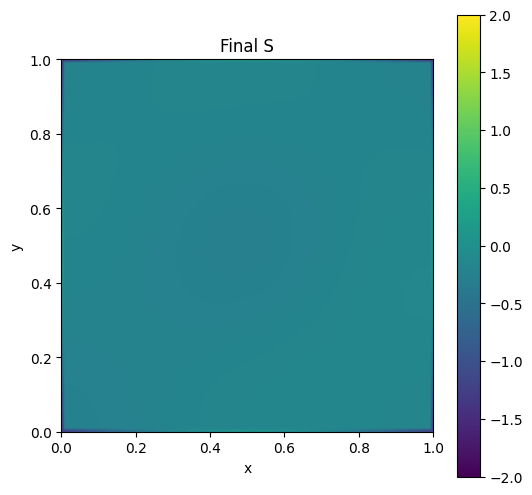

K range: -0.3774109457088767 0.8518848261437405


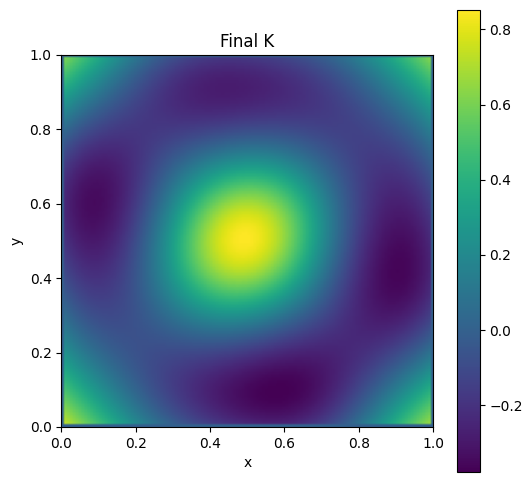

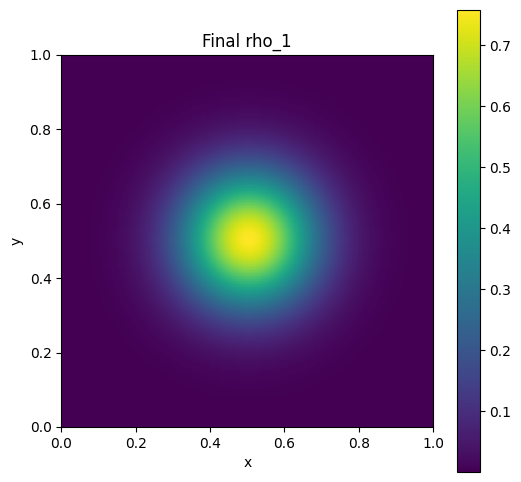

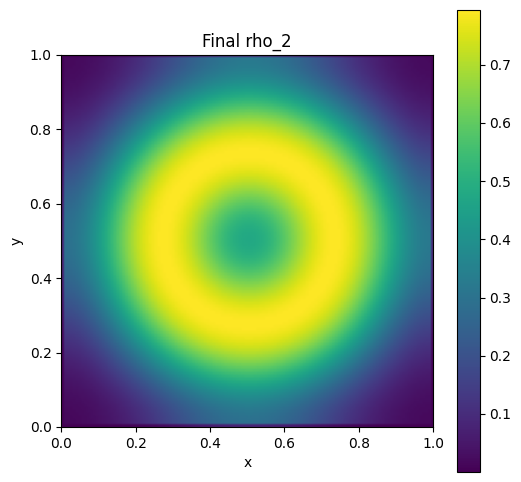

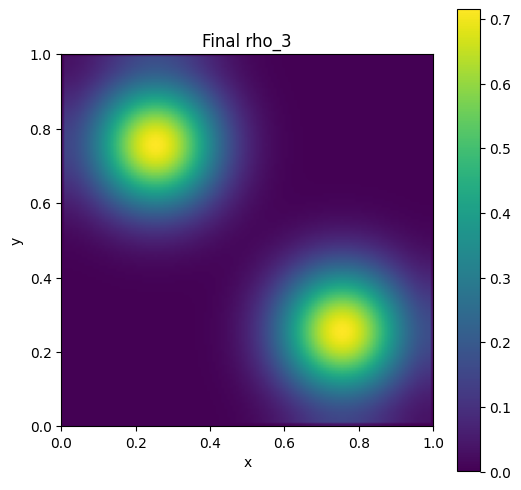

In [10]:
def plot_field(field, title="", vmin=None, vmax=None):
    plt.figure()
    plt.imshow(field.T, origin='lower', extent=[0, Lx, 0, Ly],
               vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


# Final S
plot_field(S_curr, title="Final S", vmin=-2.0, vmax=2.0)

# Final K and its range
K_final, _, _ = compute_curvature(S_curr, h)
print("K range:", K_final.min(), K_final.max())
plot_field(K_final, title="Final K")

# Final species fields
for i in range(n_species):
    plot_field(rho_curr[i], title=f"Final rho_{i+1}")
